# Continuous housing investment with frictions: EGM(FUES) vs NEGM(FUES)

In [ ]:
import warnings
warnings.filterwarnings('ignore', message='.*IProgress.*')

import numpy as np
import sys, os, time

REPO_ROOT = os.path.abspath('../../..')
sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)
os.environ['FUES_RETURN_GRIDS'] = '1'

from examples.durables.solve import solve
from examples.durables.horses.simulate import (
    simulate_lifecycle, evaluate_euler_c, evaluate_euler_h,
)
from examples.durables.outputs import (
    setup_nb_style,
    FilteredStdout, get_timing,
    print_solve_summary, build_comparison_row,
    nb_plot_adjuster_comparison, nb_plot_adjuster_egm,
    nb_plot_keeper_egm, nb_plot_keeper_policy,
    plot_euler_histogram, plot_lifecycle,
    compute_euler_stats,
    generate_vertical_comparison,
    generate_cohort_table,
    nb_plot_value_functions,
)
from IPython.display import Markdown

setup_nb_style()
SYNTAX = 'examples/durables/mod/separable'
print('Ready')

## 2. Solve

In [ ]:
OVERRIDES = dict(
    setting_overrides={
        'store_cntn': 1, 'N_wage': 4,
        'n_w': 300, 'n_a': 300, 'n_h': 600, 'n_sections': 1, 'sigma_w': 0.12   
    },
    calib_overrides={
        't0': 20, 'tau': 0.07
    },
)

labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
results = {}
real_stdout = sys.stdout
for method in ['FUES', 'NEGM']:
    print(f'{labels[method]}', flush=True)
    t0 = time.time()
    sys.stdout = FilteredStdout(real_stdout)
    try:
        nest, grids = solve(
            SYNTAX, method=method,
            verbose=False, progress='bar',
            **OVERRIDES)
    finally:
        sys.stdout = real_stdout
    elapsed = time.time() - t0
    timing = get_timing(nest)
    results[method] = {
        'nest': nest, 'grids': grids,
        'timing': timing, 'elapsed': elapsed,
    }

print_solve_summary(results)

EGM(FUES)


    solve(method=...) is deprecated; use method_overrides instead.
    Settings symbol 'extrap_policy' (for cntn_to_dcsn_mover.extrap_policy) not declared in stage symbols.settings
    Settings symbol 'clamp_max_factor' (for cntn_to_dcsn_mover.clamp_max_factor) not declared in stage symbols.settings
    Settings symbol 'extrap_policy' (for dcsn_to_arvl_mover.extrap_policy) not declared in stage symbols.settings
    Settings symbol 'clamp_max_factor' (for dcsn_to_arvl_mover.clamp_max_factor) not declared in stage symbols.settings
    Settings symbol 'n_sections' (for cntn_to_dcsn_mover.n_sections) not declared in stage symbols.settings
Solving: 100%|██████████| 51/51 [00:33<00:00,  1.52it/s, age=20, avg_adj_ms=18, avg_keeper_ms=74]

NEGM(FUES)



    solve(method=...) is deprecated; use method_overrides instead.
    Settings symbol 'extrap_policy' (for cntn_to_dcsn_mover.extrap_policy) not declared in stage symbols.settings
    Settings symbol 'clamp_max_factor' (for cntn_to_dcsn_mover.clamp_max_factor) not declared in stage symbols.settings
    Settings symbol 'extrap_policy' (for dcsn_to_arvl_mover.extrap_policy) not declared in stage symbols.settings
    Settings symbol 'clamp_max_factor' (for dcsn_to_arvl_mover.clamp_max_factor) not declared in stage symbols.settings
    Settings symbol 'n_sections' (for cntn_to_dcsn_mover.n_sections) not declared in stage symbols.settings
Solving: 100%|██████████| 51/51 [00:29<00:00,  1.73it/s, age=20, avg_adj_ms=22, avg_keeper_ms=77]


  51 periods, ages 20–70
  r=0.045, R=1.045, r_H=0, R_H=1.0, beta=0.945, alpha=0.7, gamma_c=3.5, gamma_h=1.5, kappa=0.06, sigma=0.001, delta=0, tau=0.07, chi=0, theta=1.3498, K=1.3, lambdas=[4.329982, 0.610214, -0.0209832, 0.0003132, -1.72e-06, 0.0199949, 4.76e-05], tau_av=30
  n_a=300, n_h=600, n_w=300, N_wage=4

  Method            Keeper    Adjuster      Tenure     Total
                (ms/period)  (ms/period)  (ms/period)     (sec)
  ────────────────────────────────────────────────────────────
  EGM(FUES)             74          18         345        34
  NEGM(FUES)            77          22         346        30


## 3. Adjuster policies

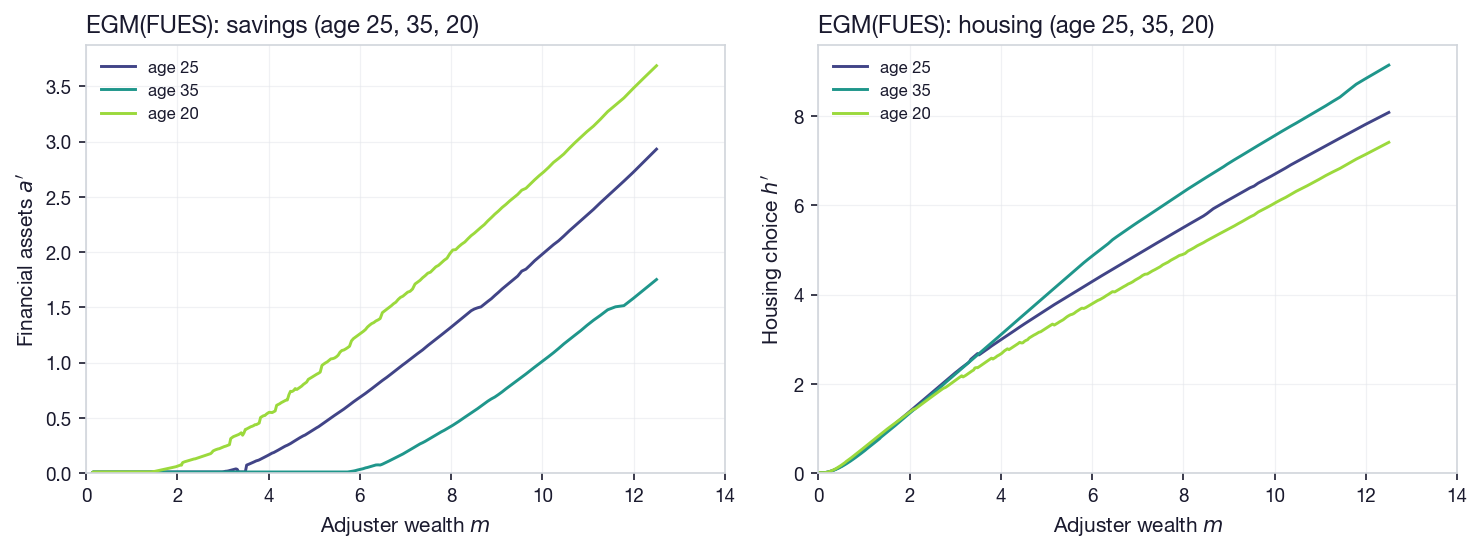

In [ ]:
fig = nb_plot_adjuster_comparison(
    results, results['FUES']['grids'],
    plot_t=[25, 35, 20], methods_filter=['FUES'], i_z=2)

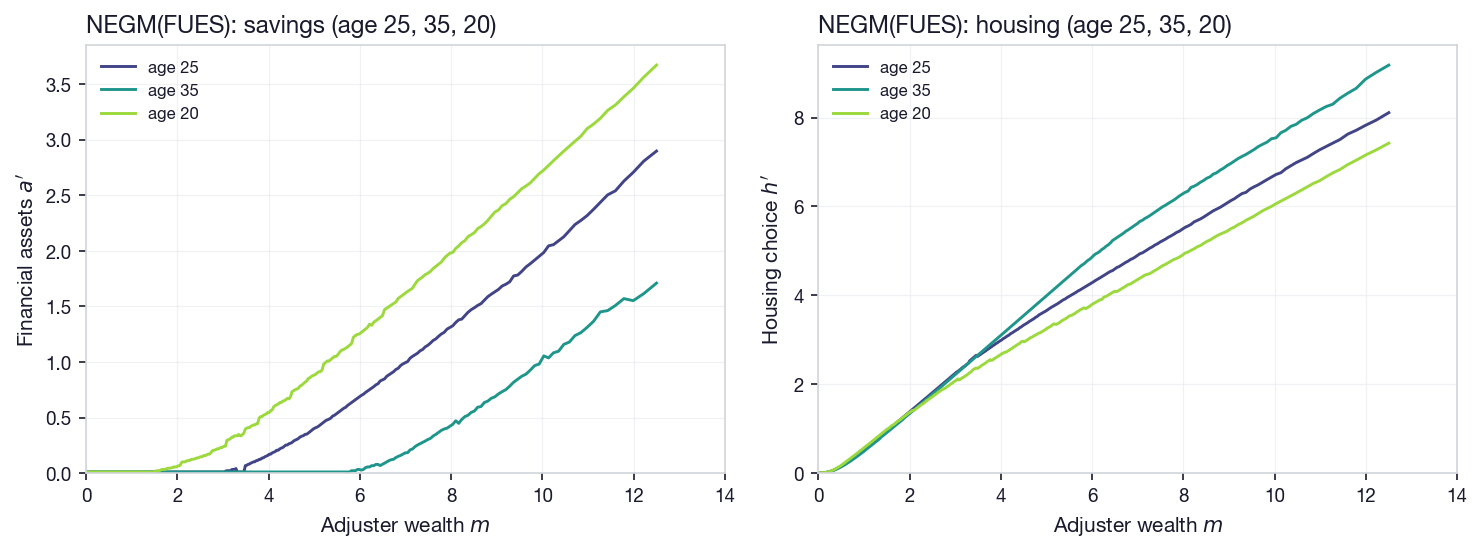

In [ ]:
fig = nb_plot_adjuster_comparison(
    results, results['NEGM']['grids'],
    plot_t=[25, 35, 20], methods_filter=['NEGM'], i_z=2)

#fig = nb_plot_value_functions(
#    results, results['FUES']['grids'], plot_t=67)


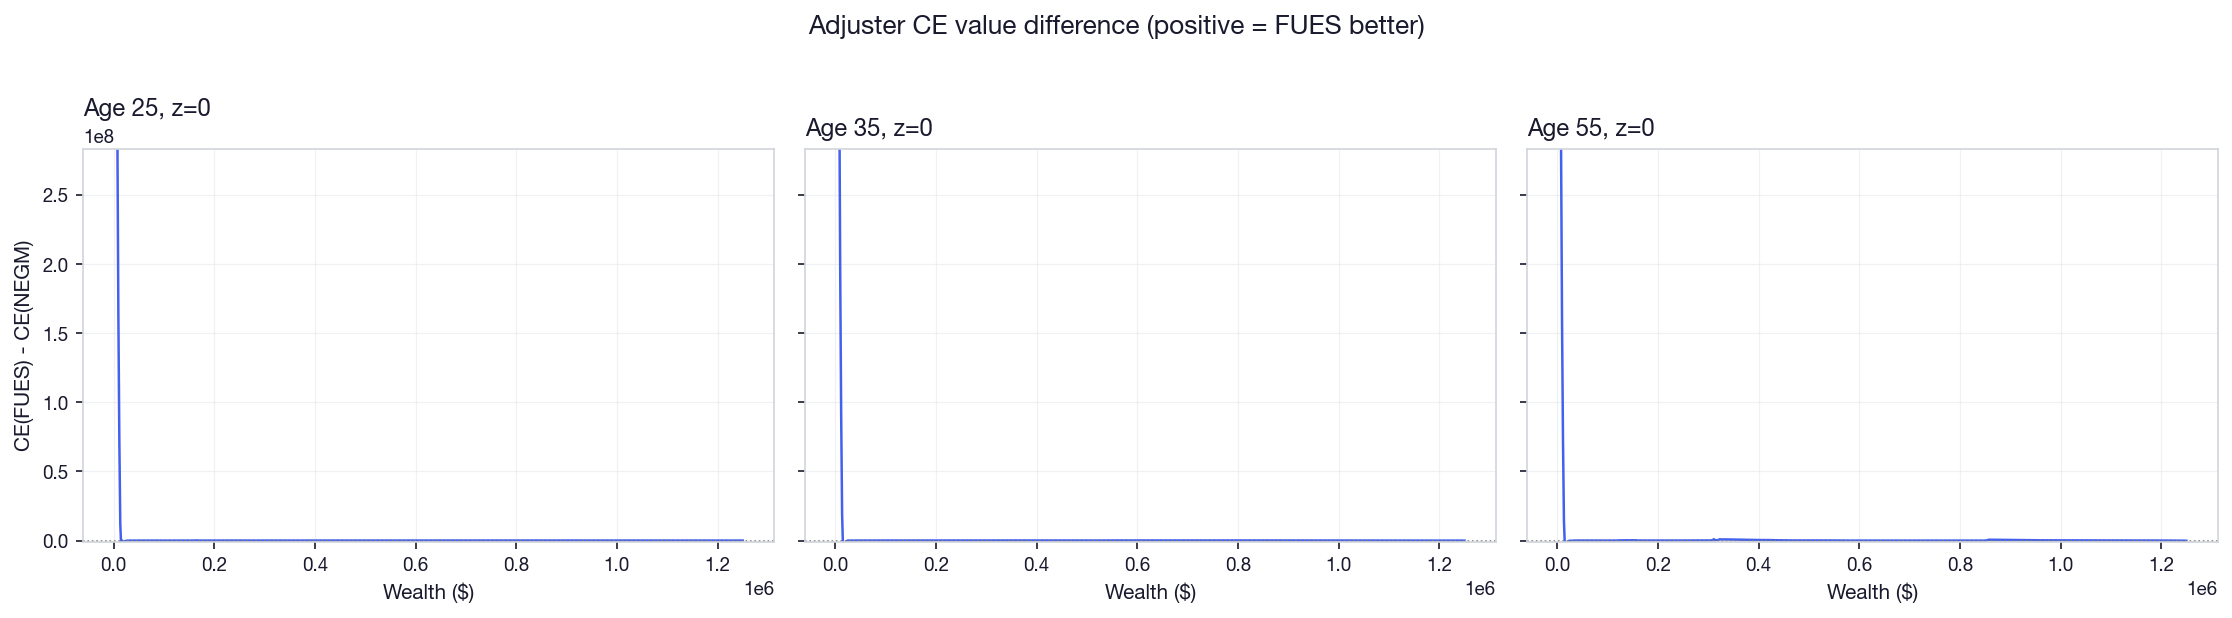

  iw       wealth         V_FUES         V_NEGM           diff
   0     0.020450      -153.2603 -27999999999999995904.0000 27999999999999995904.0000         0.0100
   1     0.039240      -153.2603     -6078.9609      5925.7005         0.0100
   2     0.058074      -153.2603     -1133.3023       980.0420         0.0100
   3     0.076952      -153.2603      -469.4805       316.2202         0.0100
   4     0.095873      -153.2603      -277.0968       123.8364         0.0100
   5     0.114839      -153.2603      -199.3539        46.0935         0.0100
   6     0.133849      -153.2603      -161.3949         8.1346         0.0100
   7     0.152904      -142.6104      -140.0340        -2.5763         0.0123
   8     0.172004      -126.7766      -125.9933        -0.7833         0.0161
   9     0.191149      -116.8615      -116.1581        -0.7034         0.0205
  10     0.210339      -109.1920      -108.9439        -0.2481         0.0255
  11     0.229575      -103.5028      -103.4489        -

In [ ]:
# ── CE-transformed adjuster value: FUES vs NEGM difference ──
import matplotlib.pyplot as plt
from examples.durables.outputs.notebook import ce_utility

_st = results['FUES']['nest']['periods'][0]['stages']['keeper_cons']
_rho = float(_st.calibration.get('gamma_c', _st.calibration.get('rho', 2.0)))
_norm = 1.0 / float(_st.settings['normalisation'])
we = results['FUES']['grids']['we']
sol_f = {s['t']: s for s in results['FUES']['nest']['solutions']}
sol_n = {s['t']: s for s in results['NEGM']['nest']['solutions']}

plot_ages = [25, 35, 55]
iz = 0

def _ce_arr(V):
    """Per-grid-point CE transform."""
    inner = (1.0 - _rho) * V
    return np.where(inner > 0, inner ** (1.0 / (1.0 - _rho)), np.nan) * _norm

fig, axes = plt.subplots(1, len(plot_ages), figsize=(5 * len(plot_ages), 4), sharey=True)
for ax, age in zip(axes, plot_ages):
    Vf = sol_f[age]['adjuster_cons']['dcsn']['V'][iz]
    Vn = sol_n[age]['adjuster_cons']['dcsn']['V'][iz]
    ce_f = _ce_arr(Vf)
    ce_n = _ce_arr(Vn)
    diff = ce_f - ce_n

    ax.plot(we * _norm, diff * _norm, lw=1.2, color='#4361ee')
    ax.axhline(0, color='gray', ls=':', lw=0.8)
    ax.set_xlabel('Wealth ($)')
    ax.set_title(f'Age {age}, z={iz}')
    valid = diff[np.isfinite(diff)]
    if len(valid) > 0:
        ax.set_ylim(np.percentile(valid * _norm, 1), np.percentile(valid * _norm, 99))

axes[0].set_ylabel('CE(FUES) - CE(NEGM)')
fig.suptitle('Adjuster CE value difference (positive = FUES better)', y=1.02)
fig.tight_layout()
plt.show()

we = results['FUES']['grids']['we']                                                                                                                                                                
sol_f = {s['t']: s for s in results['FUES']['nest']['solutions']}                                                                                                                                  
sol_n = {s['t']: s for s in results['NEGM']['nest']['solutions']}                                                                                                                                  
                                                        
age = 35                                                                                                                                                                                           
iz = 0                                                    
Vf = sol_f[age]['adjuster_cons']['dcsn']['V'][iz]                                                                                                                                                  
Vn = sol_n[age]['adjuster_cons']['dcsn']['V'][iz]        
Hn = sol_n[age]['adjuster_cons']['dcsn']['h_choice'][iz]  
                                                                                                                                                                                                    
print(f"{'iw':>4s} {'wealth':>12s} {'V_FUES':>14s} {'V_NEGM':>14s} {'diff':>14s}")                                                                                                                 
for iw in range(20):                                                                                                                                                                               
    print(f"{iw:4d} {we[iw]:12.6f} {Vf[iw]:14.4f} {Vn[iw]:14.4f} {Vf[iw]-Vn[iw]:14.4f} {Hn[iw]:14.4f}") 


age = 35                                                  
iz = 0                                                                                                                                                                                             
cntn = sol_f[age]['adjuster_cons'].get('cntn')            
if cntn:
    refined = cntn.get('_refined', {})
    r = refined.get(iz)
    if r:
        m = r['m_endog']                                                                                                                                                                           
        v = r['vf']
        h = r['h_nxt_eval']                                                                                                                                                                        
        # Show points in the desert region (m < 0.3)                                                                                                                                               
        mask = m < 0.3
        print(f"FUES points with m < 0.3 ({np.sum(mask)} of {len(m)}):")                                                                                                                           
        for i in np.where(mask)[0]:                                                                                                                                                                
            print(f"  m={m[i]:.6f}  V={v[i]:.2f}  h={h[i]:.6f}")  


# V diff across all ages and z, weighted by where agents actually are                                                                                                                              
we = grids['we']                                                                                                                                                                                   
total_diff = np.zeros(len(we))                                                                                                                                                                     
count = 0                                                                                                                                                                                          
for age in range(20, 70):                                 
    if age not in sol_f or age not in sol_n:                                                                                                                                                       
        continue                                                                                                                                                                                   
    Vf = sol_f[age]['adjuster_cons']['dcsn']['V']
    Vn = sol_n[age]['adjuster_cons']['dcsn']['V']                                                                                                                                                  
    for iz in range(Vf.shape[0]):                                                                                                                                                                  
        diff = Vf[iz] - Vn[iz]                                                                                                                                                                     
        diff[np.isinf(diff) | np.isnan(diff)] = 0                                                                                                                                                  
        total_diff += diff                                                                                                                                                                         
        count += 1
                                                                                                                                                                                                    
mean_diff = total_diff / count                            
print(f"Mean V diff (FUES-NEGM) across all ages/z:")                                                                                                                                               
print(f"  Overall mean: {np.mean(mean_diff):.4f}")                                                                                                                                                 
print(f"  Points where FUES wins: {np.sum(mean_diff > 0)}/{len(we)}")
print(f"  Points where NEGM wins: {np.sum(mean_diff < 0)}/{len(we)}")                                                                                                                              
print(f"  Worst FUES loss: {np.min(mean_diff):.4f} at w={we[np.argmin(mean_diff)]:.4f}")


# Count grid points where tenure choice differs                                                                                                                                                    
n_diff = 0                                                
n_total = 0                                                                                                                                                                                        
for age in range(20, 70):
    if age not in sol_f or age not in sol_n:                                                                                                                                                       
        continue                                          
    adj_f = sol_f[age]['tenure']['dcsn']['adj']                                                                                                                                                    
    adj_n = sol_n[age]['tenure']['dcsn']['adj']                                                                                                                                                    
    diff = (np.round(adj_f) != np.round(adj_n))                                                                                                                                                    
    n_diff += np.sum(diff)                                                                                                                                                                         
    n_total += diff.size                                                                                                                                                                           
                                                        
print(f"Tenure adj/keep disagree: {n_diff}/{n_total} = {100*n_diff/n_total:.2f}%")


# Which direction do the flips go?                                                                                                                                                                 
fues_adj_negm_keep = 0                                                                                                                                                                             
fues_keep_negm_adj = 0                                                                                                                                                                             
for age in range(20, 70):                                                                                                                                                                          
    if age not in sol_f or age not in sol_n:                                                                                                                                                       
        continue                                                                                                                                                                                   
    adj_f = np.round(sol_f[age]['tenure']['dcsn']['adj'])
    adj_n = np.round(sol_n[age]['tenure']['dcsn']['adj'])                                                                                                                                          
    fues_adj_negm_keep += np.sum((adj_f == 1) & (adj_n == 0))
    fues_keep_negm_adj += np.sum((adj_f == 0) & (adj_n == 1))                                                                                                                                      
                                                                                                                                                                                                    
print(f"FUES=adjust, NEGM=keep: {fues_adj_negm_keep}")                                                                                                                                             
print(f"FUES=keep, NEGM=adjust: {fues_keep_negm_adj}")                                                                                                                                             
print(f"Net: NEGM adjusts {fues_keep_negm_adj - fues_adj_negm_keep} more states") 


a_grid = grids['a']                                       
h_grid = grids['h']                                                                                                                                                                                
flip_a = []
flip_h = []                                                                                                                                                                                        
for age in [30, 40, 50]:                                  
    if age not in sol_f:                                                                                                                                                                           
        continue
    adj_f = np.round(sol_f[age]['tenure']['dcsn']['adj'])                                                                                                                                          
    adj_n = np.round(sol_n[age]['tenure']['dcsn']['adj']) 
    mask = (adj_f == 0) & (adj_n == 1)                                                                                                                                                             
    for iz in range(mask.shape[0]):
        ia, ih = np.where(mask[iz])                                                                                                                                                                
        flip_a.extend(a_grid[ia])                         
        flip_h.extend(h_grid[ih])                                                                                                                                                                  
                                                                                                                                                                                                    
flip_a = np.array(flip_a)
flip_h = np.array(flip_h)                                                                                                                                                                          
print(f"FUES=keep, NEGM=adjust flips at ages 30,40,50:")  
print(f"  a: mean={flip_a.mean():.3f}, median={np.median(flip_a):.3f}, "                                                                                                                           
    f"p10={np.percentile(flip_a,10):.3f}, p90={np.percentile(flip_a,90):.3f}")                                                                                                                   
print(f"  h: mean={flip_h.mean():.3f}, median={np.median(flip_h):.3f}, "                                                                                                                           
    f"p10={np.percentile(flip_h,10):.3f}, p90={np.percentile(flip_h,90):.3f}") 



from examples.durables.mod.separable.callables import _u                                                                                                                                           
cal = results['FUES']['nest']['periods'][0]['stages']['keeper_cons'].calibration                                                                                                                   
alpha = float(cal['alpha'])                                                                                                                                                                        
gc = float(cal['gamma_c'])                                                                                                                                                                         
gh = float(cal['gamma_h'])                                                                                                                                                                         
kappa = float(cal['kappa'])                               
chi = float(cal['chi'])                                                                                                                                                                            
                                                        
age = 35                                                                                                                                                                                           
iz = 0                                                    
Cf = sol_f[age]['adjuster_cons']['dcsn']['c'][iz]                                                                                                                                                  
Hf = sol_f[age]['adjuster_cons']['dcsn']['h_choice'][iz]                                                                                                                                           
Cn = sol_n[age]['adjuster_cons']['dcsn']['c'][iz]                                                                                                                                                  
Hn = sol_n[age]['adjuster_cons']['dcsn']['h_choice'][iz]                                                                                                                                           
Vf = sol_f[age]['adjuster_cons']['dcsn']['V'][iz]         
Vn = sol_n[age]['adjuster_cons']['dcsn']['V'][iz]                                                                                                                                                  
                                                        
print(f"{'iw':>4s} {'w':>8s} {'u_FUES':>10s} {'u_NEGM':>10s} {'u_diff':>10s} {'V_diff':>10s}")                                                                                                     
for iw in range(20):                                      
    w = we[iw]                                                                                                                                                                                     
    uf = _u(Cf[iw], Hf[iw], chi, alpha, gc, gh, kappa)                                                                                                                                             
    un = _u(Cn[iw], Hn[iw], chi, alpha, gc, gh, kappa)                                                                                                                                             
    vdiff = Vf[iw] - Vn[iw]                                                                                                                                                                        
    print(f"{iw:4d} {w:8.4f} {uf:10.4f} {un:10.4f} {uf-un:10.4f} {vdiff:10.4f}")                                                                                                                   
                                                                                                                                                                                                    
cntn = sol_f[35]['adjuster_cons'].get('cntn')                                                                                                                                                      
if cntn:                                                                                                                                                                                           
    r = cntn['_refined'][0]
    print(f"m_clean[0] = {r['m_endog'][0]:.6f}")                                                                                                                                                   
    print(f"we_grid[0] = {we[0]:.6f}")                                                                                                                                                             
    print(f"we_grid[6] = {we[6]:.6f}")                                                                                                                                                             
                                        
                                                            


## 4. Adjuster EGM grid

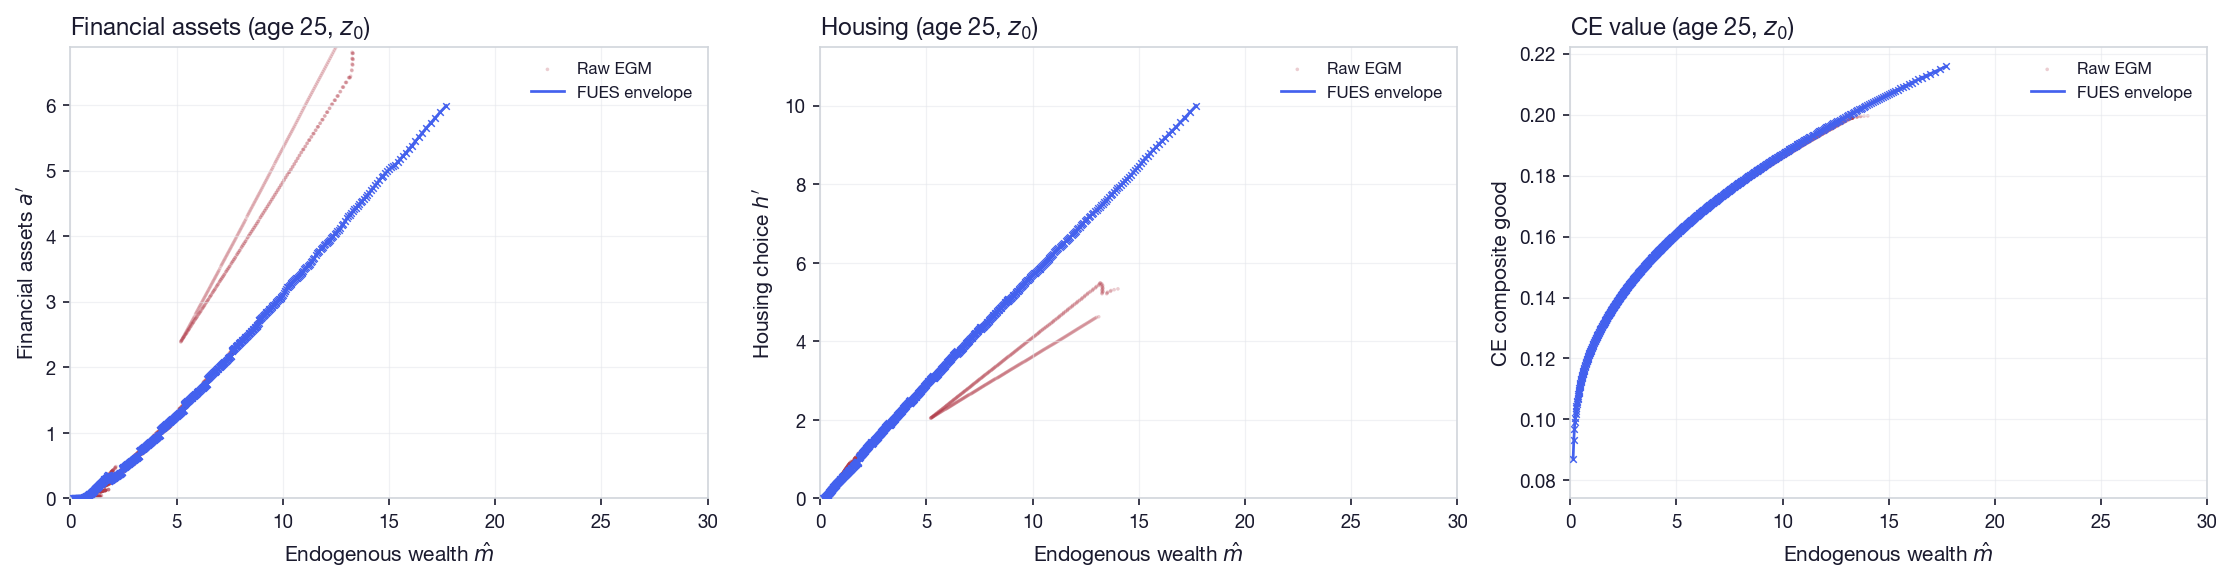

In [ ]:
fig = nb_plot_adjuster_egm(
    results['FUES']['nest'],
    results['FUES']['grids'], plot_t=25, xlim =30, i_z=0)

In [ ]:
# ── Interactive plotly (zoom/pan to inspect dense crossings) ──
try:
    from examples.durables.outputs import nb_plot_adjuster_egm_interactive
    fig_a, fig_h, fig_v = nb_plot_adjuster_egm_interactive(
        results['FUES']['nest'], results['FUES']['grids'], plot_t=42, i_z=0)
    fig_a.show()
    fig_h.show()
    fig_v.show()
except Exception as e:
    print(f'Interactive plots skipped: {e}')

## 5. Keeper policies

  age 25, z=0: m_clean[0]=0.138625, len=639
  age 25, z=1: m_clean[0]=0.140112, len=600
  age 35, z=0: m_clean[0]=0.140057, len=628
  age 35, z=1: m_clean[0]=0.140762, len=600
  age 55, z=0: m_clean[0]=0.139885, len=550
  age 55, z=1: m_clean[0]=0.140606, len=551


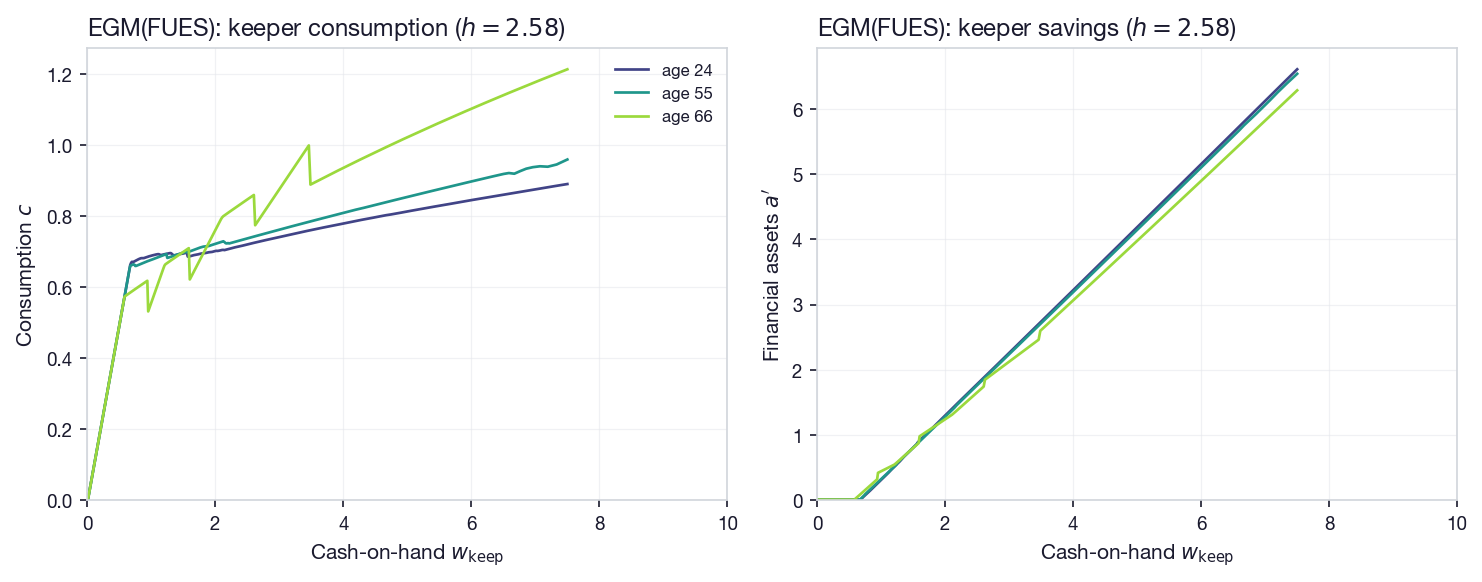

In [ ]:
fig = nb_plot_keeper_policy(results, results['FUES']['grids'],
                           plot_t=[24, 55, 66], methods_filter=['FUES'], xlim=10, i_z=3)
sol_f = {s['t']: s for s in results['FUES']['nest']['solutions']}                                                                                                                                  
for age in [25, 35, 55]:                                                                                                                                                                           
    ref = sol_f[age]['adjuster_cons'].get('cntn', {})
    for iz in range(min(2, len(grids['z']))):                                                                                                                                                      
        r = ref.get('_refined', {}).get(iz)               
        if r is not None:                                                                                                                                                                          
            print(f"  age {age}, z={iz}: m_clean[0]={r['m_endog'][0]:.6f}, "
                f"len={len(r['m_endog'])}")

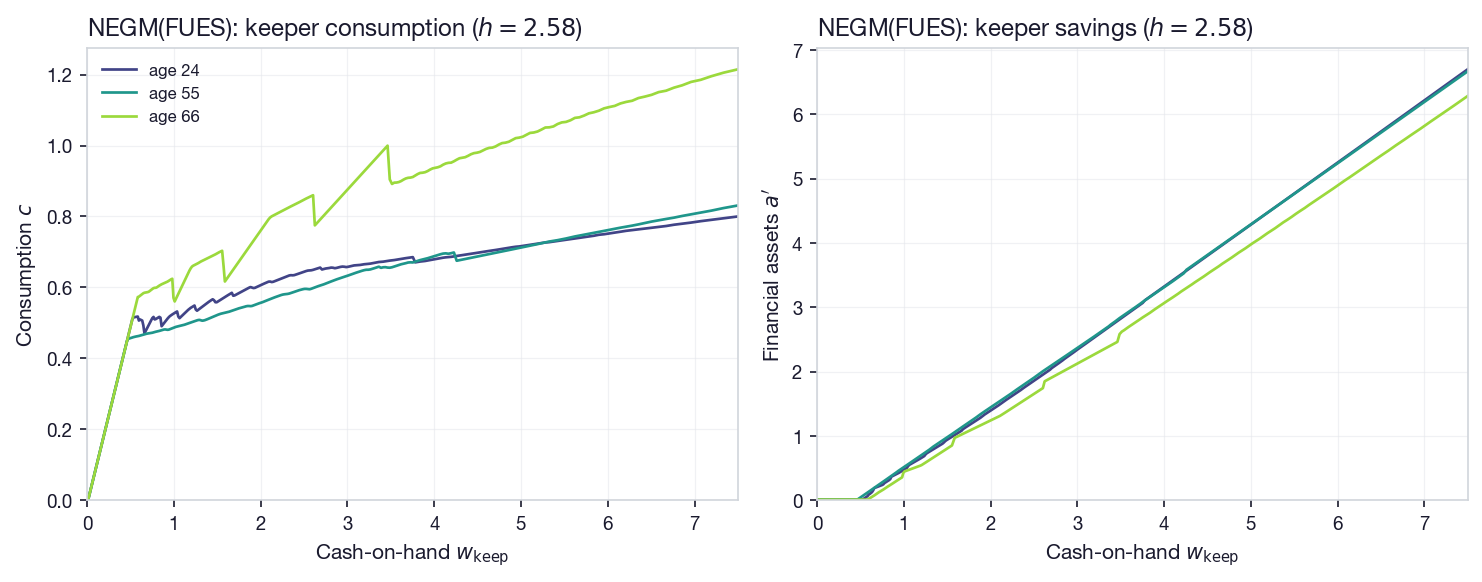

In [ ]:
fig = nb_plot_keeper_policy(results, results['NEGM']['grids'],
                           plot_t=[24, 55, 66], methods_filter=['NEGM'])

## 6. Euler equation errors

In [ ]:
euler_results = {}

for method in ['FUES', 'NEGM']:
    r = results[method]
    sim_data = simulate_lifecycle(r['nest'], r['grids'], N=10_000, seed=21, init_dispersion=2)       
    euler_c = evaluate_euler_c(sim_data, r['nest'], r['grids'])
    euler_h = evaluate_euler_h(sim_data, r['nest'], r['grids'])
    euler_results[method] = {
        'euler_c': euler_c, 'euler_h': euler_h, 'euler': euler_c,
        'stats_c': compute_euler_stats(euler_c, sim_data['discrete']),
        'stats_h': compute_euler_stats(euler_h, sim_data['discrete']),
        'stats': compute_euler_stats(euler_c, sim_data['discrete']),
        'sim_data': sim_data,
    }

print('Simulation complete (N = 10,000)')

Simulation complete (N = 10,000)


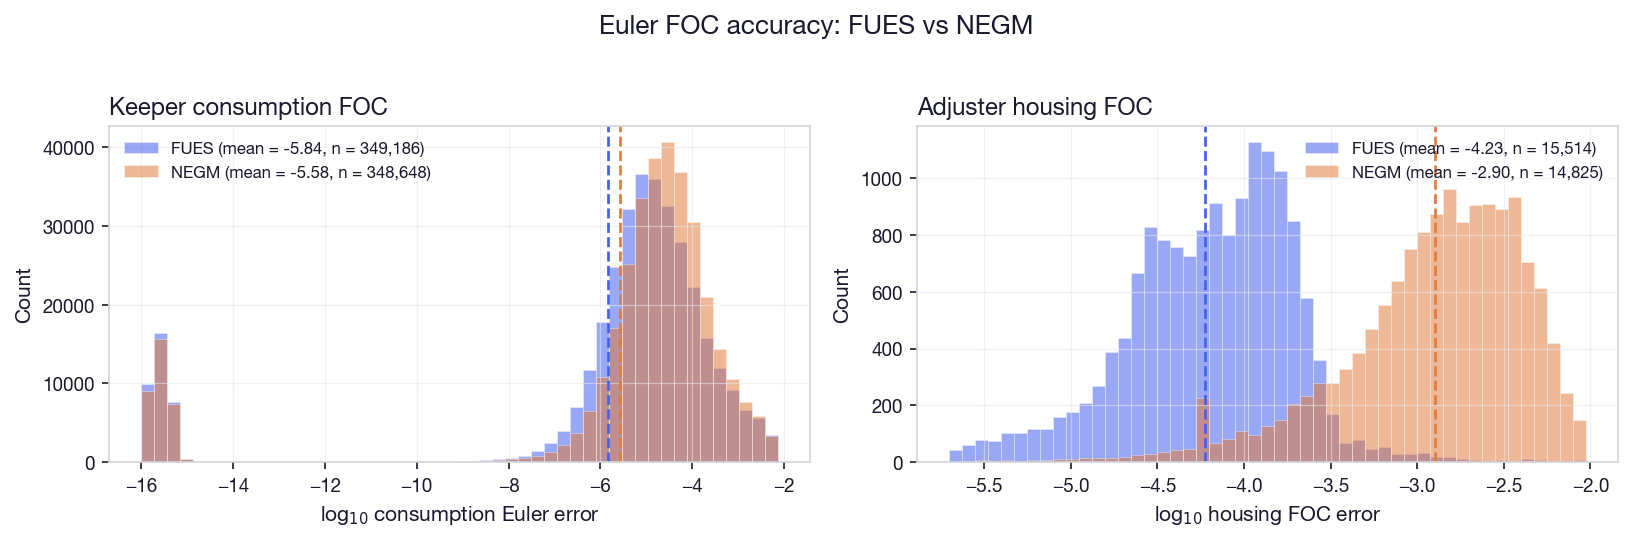

In [ ]:
fig = plot_euler_histogram(euler_results)

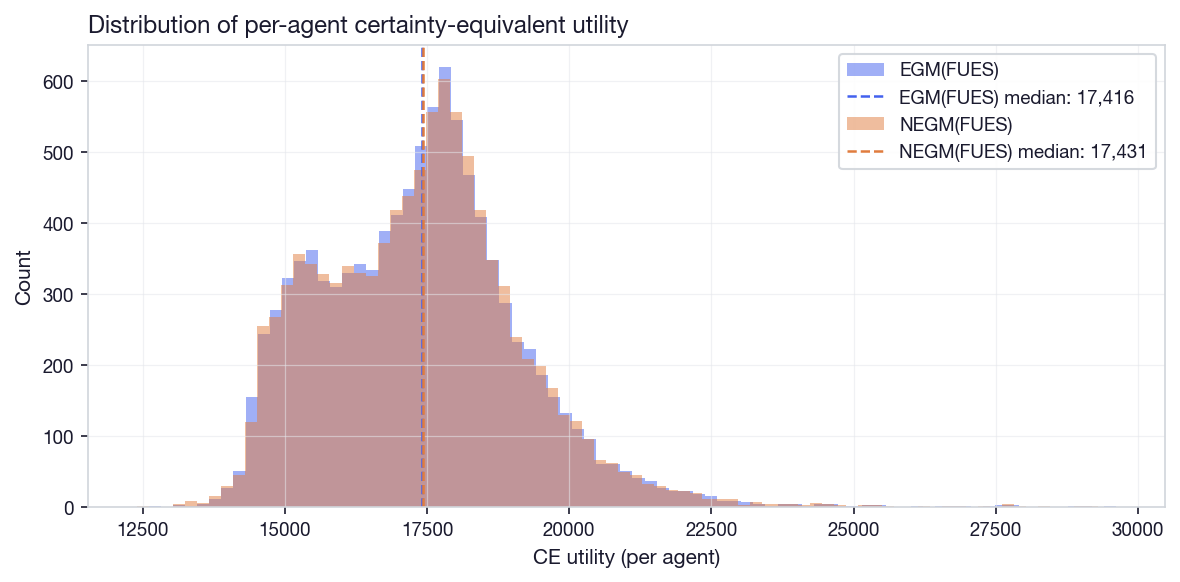

100 agents in bottom 1%
  agent 112: diverges at age 0, d_fues=-1, d_negm=-1, c_fues=nan, c_negm=nan
  agent 185: diverges at age 0, d_fues=-1, d_negm=-1, c_fues=nan, c_negm=nan
  agent 234: diverges at age 31, d_fues=0, d_negm=1, c_fues=0.3283, c_negm=0.3079
  agent 317: diverges at age 0, d_fues=-1, d_negm=-1, c_fues=nan, c_negm=nan
  agent 532: diverges at age 0, d_fues=-1, d_negm=-1, c_fues=nan, c_negm=nan
Agent 234 at age 38: a=0.1455, h=0.4714, z_idx=1
  EGM(FUES): adj_interp=1.000000 -> d=1
  NEGM(FUES): adj_interp=1.000000 -> d=1
Adjusters: 96558
  w_approx min: 0.0204
  w_approx < 0.14: 7171
  w_approx < 0.5: 26283
FUES: mean discounted utility = -33.164713
NEGM: mean discounted utility = -33.140225

FUES: N=10000, mean=-33.164713
    pct       cutoff    cond_mean      n
    0-  1 [  -70.8834,   -51.6361] mean=  -54.304439  n=  100
    1-  5 [  -51.6361,   -47.9778] mean=  -49.517043  n=  400
    5- 10 [  -47.9778,   -45.1059] mean=  -46.489067  n=  500
   10- 25 [  -45.1059, 

In [ ]:
# ── Per-agent CE utility histogram ──
import matplotlib.pyplot as plt
from dcsmm.fues.helpers.math_funcs import interp_as_scalar                                                                                                                                         


_st = results['FUES']['nest']['periods'][0]['stages']['keeper_cons']
_rho = float(_st.calibration.get('gamma_c', _st.calibration.get('rho', 2.0)))
_norm = 1.0 / float(_st.settings['normalisation'])
_labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
_colors = {'FUES': '#4361ee', 'NEGM': '#e07c3e'}

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
for method in ['FUES', 'NEGM']:
    npv = euler_results[method]['sim_data']['npv_utility']
    valid = npv[np.isfinite(npv) & (npv != 0)]
    inner = (1.0 - _rho) * valid
    ce = np.where(inner > 0, inner ** (1.0 / (1.0 - _rho)), np.nan) * _norm
    ce = ce[np.isfinite(ce)]
    ax.hist(ce, bins=80, alpha=0.5, label=_labels[method], color=_colors[method])
    ax.axvline(np.median(ce), color=_colors[method], ls='--', lw=1.2,
               label=f'{_labels[method]} median: {np.median(ce):,.0f}')

ax.set_xlabel('CE utility (per agent)')
ax.set_ylabel('Count')
ax.set_title('Distribution of per-agent certainty-equivalent utility')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


# Find agents where FUES CE << NEGM CE                                                                                                                                                                                                                                                                                   
sd_f = euler_results['FUES']['sim_data']                  
sd_n = euler_results['NEGM']['sim_data']                                                                                                                                                                                                                                                                                 
npv_f = sd_f['npv_utility']
npv_n = sd_n['npv_utility']                                                                                                                                                                                                                                                                                              
# agents where FUES NPV is much worse                     
bad = np.where(npv_f < np.percentile(npv_f, 1))[0]                                                                                                                                                                                                                                                                       
print(f"{len(bad)} agents in bottom 1%")                                                                                                                                                                                                                                                                                 
# first period where c diverges significantly                                                                                                                                                                                                                                                                            
for i in bad[:5]:                                                                                                                                                                                                                                                                                                        
    diff = np.abs(sd_f['c'][:, i] - sd_n['c'][:, i])                                                                                                                                                                                                                                                                     
    t_div = np.nanargmax(diff > 0.01)                                                                                                                                                                                                                                                                                    
    print(f"  agent {i}: diverges at age {t_div}, "                                                                                                                                                                                                                                                                      
        f"d_fues={sd_f['discrete'][t_div,i]}, "         
        f"d_negm={sd_n['discrete'][t_div,i]}, "                                                                                                                                                                                                                                                                        
        f"c_fues={sd_f['c'][t_div,i]:.4f}, "                                                                                                                                                                                                                                                                           
        f"c_negm={sd_n['c'][t_div,i]:.4f}") 


# ── Diagnose adjust/keep margin at divergence points ──                                                                                                                                                                                                                                                                 
sd_f = euler_results['FUES']['sim_data']                                                                                                                                                                                                                                                                                 
sd_n = euler_results['NEGM']['sim_data']                                                                                                                                                                                                                                                                                 
npv_f = sd_f['npv_utility']                                                                                                                                                                                                                                                                                              
bad = np.where(npv_f < np.percentile(npv_f, 1))[0]                                                                                                                                                                                                                                                                       
                                                                                                                                                                                                                                                                                                                        
# Pick one representative agent at the divergence age                                                                                                                                                                                                                                                                    
i = bad[2]  # agent 509                                                                                                                                                                                                                                                                                                  
t_div = 38                                                                                                                                                                                                                                                                                                               

a_i = sd_f['a'][t_div, i]                                                                                                                                                                                                                                                                                                
h_i = sd_f['h'][t_div, i]                                 
z_i = int(sd_f['z_idx'][t_div, i])                                                                                                                                                                                                                                                                                       
                                                        
print(f"Agent {i} at age {t_div}: a={a_i:.4f}, h={h_i:.4f}, z_idx={z_i}")                                                                                                                                                                                                                                                

# Look up the tenure discrete choice arrays for both methods                                                                                                                                                                                                                                                             
from interpolation.splines import eval_linear             
from interpolation.splines import extrap_options as xto                                                                                                                                                                                                                                                                  
                                                                                                                                                                                                                                                                                                                        
UG = results['FUES']['grids']['UGgrid_all']                                                                                                                                                                                                                                                                              
sol_by_t_f = {s['t']: s for s in results['FUES']['nest']['solutions']}                                                                                                                                                                                                                                                   
sol_by_t_n = {s['t']: s for s in results['NEGM']['nest']['solutions']}                                                                                                                                                                                                                                                   
                                                        
pt = np.array([a_i, h_i])                                                                                                                                                                                                                                                                                                
for method, sol_by_t, label in [                          
    ('FUES', sol_by_t_f, 'EGM(FUES)'),                                                                                                                                                                                                                                                                                   
    ('NEGM', sol_by_t_n, 'NEGM(FUES)')]:                  
    sol = sol_by_t[t_div]                                                                                                                                                                                                                                                                                                
    adj_arr = sol['tenure']['dcsn']['adj']                                                                                                                                                                                                                                                                               
    adj_val = eval_linear(UG, adj_arr[z_i], pt, xto.LINEAR)                                                                                                                                                                                                                                                              
    print(f"  {label}: adj_interp={adj_val:.6f} -> d={int(round(min(max(adj_val,0),1)))}") 


# ── Find first discrete-choice divergence ──                                                                                                                                                                                                                                                                            

                                                                                                                                                                                                                                                                                                                           
# Also check tenure arrival V (what feeds into next period's continuation)                                                                                                                                                                                                                                               
for sol in results['FUES']['nest']['solutions']:                                                                                                                                                                                                                                                                         
    t = sol['t']                                                                                                                                                                                                                                                                                                         
    arvl = sol['tenure'].get('arvl', {})                  
    V_arvl = arvl.get('V')                                                                                                                                                                                                                                                                                               
    if V_arvl is not None:
        n_pos = np.sum(V_arvl > 0)                                                                                                                                                                                                                                                                                       
        if n_pos > 0:                                                                                                                                                                                                                                                                                                    
            print(f"  age {t}: {n_pos} positive V in tenure arrival (max={V_arvl.max():.4f})")     


sd = euler_results['FUES']['sim_data']                                                                                                                                                             
adj_mask = sd['discrete'] == 1                                                                                                                                                                   
a_adj = sd['a'][adj_mask]                                                                                                                                                                          
h_adj = sd['h'][adj_mask]                                                                                                                                                                          
z_adj = sd['z_idx'][adj_mask]                                                                                                                                                                      
                                                                                                                                                                                                    
# Rough w_adj = R*a + R_H*h + income (income unknown, but check R*a + h)                                                                                                                           
w_approx = 1.045 * a_adj + 1.0 * h_adj                                                                                                                                                           
print(f"Adjusters: {np.sum(adj_mask)}")                                                                                                                                                            
print(f"  w_approx min: {w_approx.min():.4f}")                                                                                                                                                   
print(f"  w_approx < 0.14: {np.sum(w_approx < 0.14)}")                                                                                                                                             
print(f"  w_approx < 0.5: {np.sum(w_approx < 0.5)}")     

for method in ['FUES', 'NEGM']:                                                                                                                                                                    
      print(f"{method}: mean discounted utility = {euler_results[method]['sim_data']['npv_utility'].mean():.6f}")

for method in ['FUES', 'NEGM']:        
      sd = euler_results[method]['sim_data']                                                                                                                                                         
      npv = sd['npv_utility']                                                                                                                                                                        
      valid = np.isfinite(npv) & (npv != 0)                                                                                                                                                          
      npv_v = npv[valid]                                                                                                                                                                             
                                                                                                                                                                                                     
      pcts = [0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 100]                                                                                                                                              
      print(f"\n{method}: N={np.sum(valid)}, mean={npv_v.mean():.6f}")                                                                                                                               
      print(f"  {'pct':>5s} {'cutoff':>12s} {'cond_mean':>12s} {'n':>6s}")                                                                                                                           
      for i in range(len(pcts)-1):                                                                                                                                                                   
          lo = np.percentile(npv_v, pcts[i])                                                                                                                                                         
          hi = np.percentile(npv_v, pcts[i+1])                                                                                                                                                       
          mask = (npv_v >= lo) & (npv_v <= hi)                                                                                                                                                       
          if mask.sum() > 0:                                                                                                                                                                         
              print(f"  {pcts[i]:3d}-{pcts[i+1]:3d} [{lo:10.4f}, {hi:10.4f}] "
                    f"mean={npv_v[mask].mean():12.6f}  n={mask.sum():5d}") 

age = 40                                                                                                                                                                                           
sd_f = euler_results['FUES']['sim_data']
adj_mask = (sd_f['discrete'][age] == 1)                                                                                                                                                            
w_adj = 1.045 * sd_f['a'][age, adj_mask] + sd_f['h'][age, adj_mask]  # approx                                                                                                                      
c_sim = sd_f['c'][age, adj_mask]                                                                                                                                                                   
h_sim = sd_f['h_nxt'][age, adj_mask]                                                                                                                                                               
z_sim = sd_f['z_idx'][age, adj_mask]                                                                                                                                                               
                                                                                                                                                                                                    
# Realized flow utility                                   
u_realized = np.array([_u(c_sim[i], h_sim[i], 0, 0.7, 3.5, 1.5, 0.06)                                                                                                                              
                        for i in range(min(10, len(c_sim)))])                                                                                                                                      
                                                                                                                                                                                                    
# V from solved policy at same wealth                                                                                                                                                              
we = grids['we']                                                                                                                                                                                   
Vf = sol_f[age]['adjuster_cons']['dcsn']['V']                                                                                                                                                      
Cf = sol_f[age]['adjuster_cons']['dcsn']['c']                                                                                                                                                      
Hf = sol_f[age]['adjuster_cons']['dcsn']['h_choice']                                                                                                                                               
                                                                                                                                                                                                    
for i in range(min(10, len(c_sim))):                      
    iz = int(z_sim[i])                                                                                                                                                                             
    w = w_adj[i]                                          
    c_grid = interp_as_scalar(we, Cf[iz], w)                                                                                                                                                       
    h_grid = interp_as_scalar(we, Hf[iz], w)                                                                                                                                                       
    u_grid = _u(c_grid, h_grid, 0, 0.7, 3.5, 1.5, 0.06)                                                                                                                                            
    print(f"  agent {i}: w={w:.3f} c_sim={c_sim[i]:.4f} c_grid={c_grid:.4f} "                                                                                                                      
        f"h_sim={h_sim[i]:.4f} h_grid={h_grid:.4f} "                                                                                                                                             
        f"u_sim={u_realized[i]:.4f} u_grid={u_grid:.4f}")


w_adj = 1.045 * sd_f['a'][age, adj_mask] + sd_f['h'][age, adj_mask]  # MISSING INCOME                                                                                                              
                                                                                                                                                                                                     
                                                                                                                                                 
                                                        
from examples.durables.mod.separable.callables import _y_func                                                                                                                                      
cal = results['FUES']['nest']['periods'][0]['stages']['keeper_cons'].calibration                                                                                                                   
lambdas = np.array(cal['lambdas'])                                                                                                                                                                 
z_vals = grids['z']                                                                                                                                                                                
tau_av = int(cal['tau_av'])                                                                                                                                                                        
tzero = int(cal.get('tzero', 20))                                                                                                                                                                  
normalisation = float(_st.settings['normalisation'])              
                                                                                                                                                                                                    
for i in range(min(10, len(c_sim))):                                                                                                                                                               
    iz = int(z_sim[i])                                                                                                                                                                             
    a_i = sd_f['a'][age][np.where(adj_mask)[0][i]]                                                                                                                                                 
    h_i = sd_f['h'][age][np.where(adj_mask)[0][i]]                                                                                                                                                 
    income = _y_func(age, z_vals[iz], lambdas, tau_av, tzero, normalisation)
    w = 1.045 * a_i + 1.0 * h_i + income                                                                                                                                                           
    c_grid = interp_as_scalar(we, Cf[iz], w)                                                                                                                                                       
    h_grid_v = interp_as_scalar(we, Hf[iz], w)                                                                                                                                                     
    print(f"  agent {i}: w={w:.3f} c_sim={c_sim[i]:.4f} c_grid={c_grid:.4f} "                                                                                                                      
        f"h_sim={h_sim[i]:.4f} h_grid={h_grid_v:.4f} match_c={abs(c_sim[i]-c_grid)<0.001}") 

In [ ]:
# Check for positive V in FUES adjuster (should all be negative for gamma > 1)                                                                                                                                                                                                                                           
for sol in results['FUES']['nest']['solutions']:                                                                                                                                                                                                                                                                         
    t = sol['t']                                                                                                                                                                                                                                                                                                         
    V_adj = sol['adjuster_cons']['dcsn'].get('V')                                                                                                                                                                                                                                                                        
    if V_adj is not None:                                 
        n_pos = np.sum(V_adj > 0)                                                                                                                                                                                                                                                                                        
        if n_pos > 0:                                     
            print(f"  age {t}: {n_pos} positive V in adjuster (max={V_adj.max():.4f})")
                                                                                                                                                                                                                                                                                                                        
# Also check tenure arrival V (what feeds into next period's continuation)                                                                                                                                                                                                                                               
for sol in results['FUES']['nest']['solutions']:                                                                                                                                                                                                                                                                         
    t = sol['t']                                                                                                                                                                                                                                                                                                         
    arvl = sol['tenure'].get('arvl', {})                  
    V_arvl = arvl.get('V')                                                                                                                                                                                                                                                                                               
    if V_arvl is not None:
        n_pos = np.sum(V_arvl > 0)                                                                                                                                                                                                                                                                                       
        if n_pos > 0:                                                                                                                                                                                                                                                                                                    
            print(f"  age {t}: {n_pos} positive V in tenure arrival (max={V_arvl.max():.4f})")

## 7. Comparison of aggregates

In [ ]:
rows = [build_comparison_row(m, results, euler_results)
        for m in ['FUES', 'NEGM']]
Markdown(generate_vertical_comparison(
    rows, caption='EGM(FUES) vs NEGM(FUES)'))




### EGM(FUES) vs NEGM(FUES)

| | **EGM(FUES)** | **NEGM(FUES)** |
|:---|:---:|:---:|
| **Timing** |  |  |
| Keeper (ms/period) | 74 | 77 |
| Adjuster (ms/period) | 18 | 22 |
| Total (ms/period) | 437 | 444 |
| **Euler errors ($\log_{10}$)** |  |  |
| Consumption: keeper | -5.84 | -5.58 |
| Consumption: adjuster | -11.40 | -10.40 |
| Consumption: all | -6.08 | -5.78 |
| Housing: adjuster | -4.23 | -2.90 |
| **Simulation** |  |  |
| CE utility | 17,082.58 | 17,087.63 |
| Mean consumption ($) | 62,211 | 62,200 |
| Mean fin. assets ($) | 68,935 | 68,725 |
| Mean housing ($) | 249,656 | 249,955 |
| Adjustment rate (%) | 19.3 | 19.6 |

## 8. Lifecycle profiles

Lifecycle plot saved to _nb_plots/FUES/simulation/lifecycle.png
EGM(FUES)


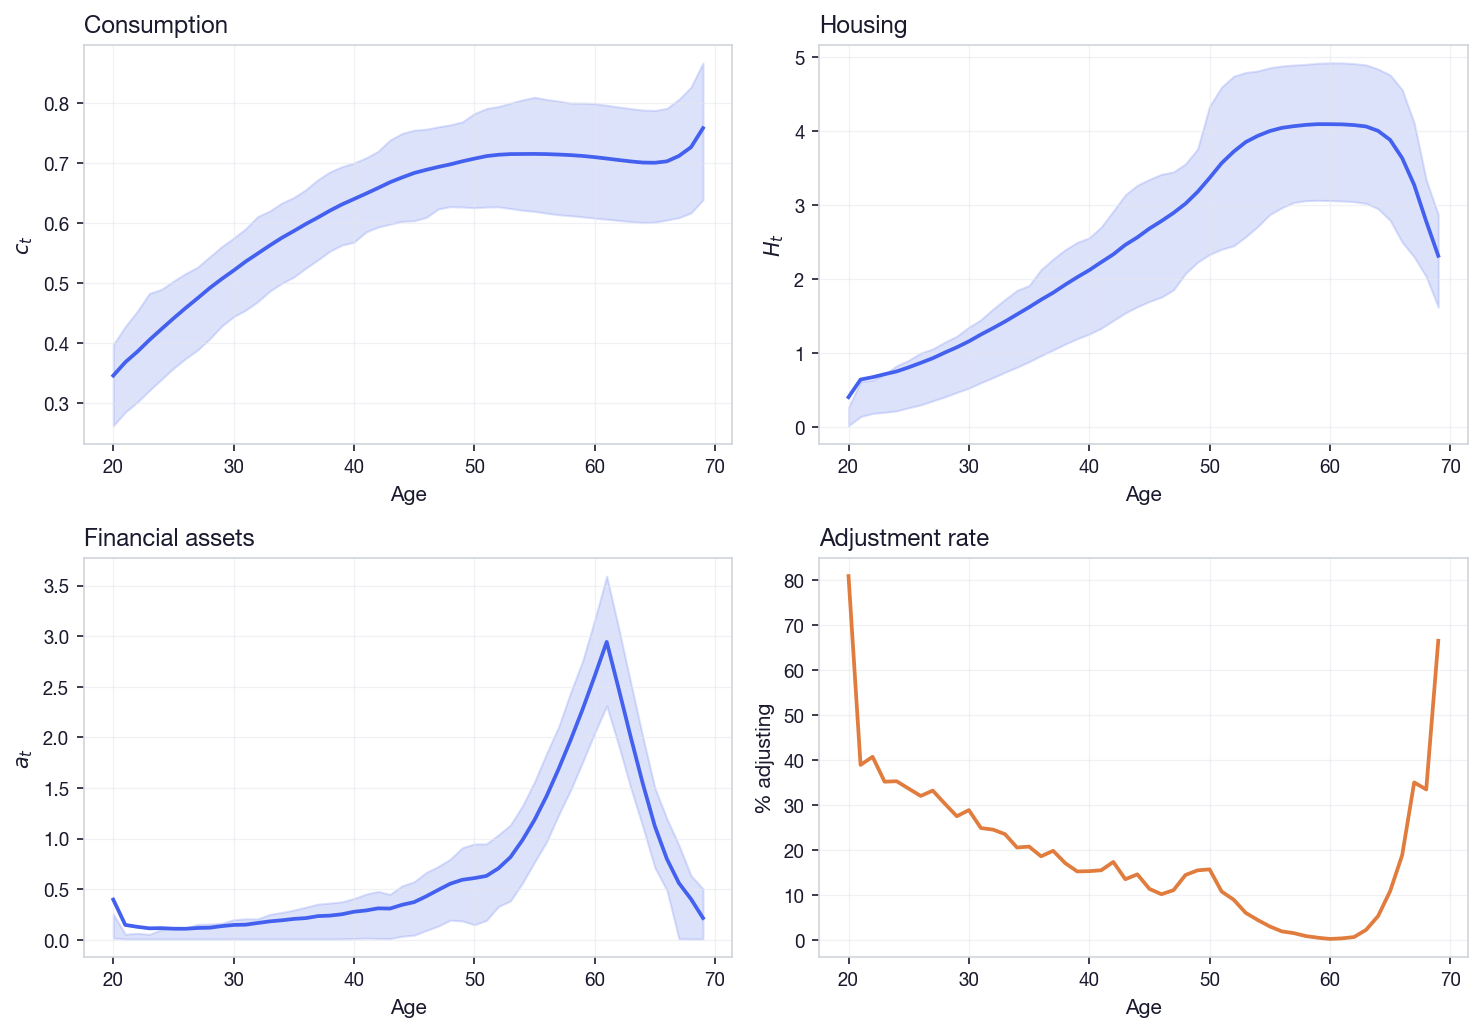

Lifecycle plot saved to _nb_plots/NEGM/simulation/lifecycle.png
NEGM(FUES)


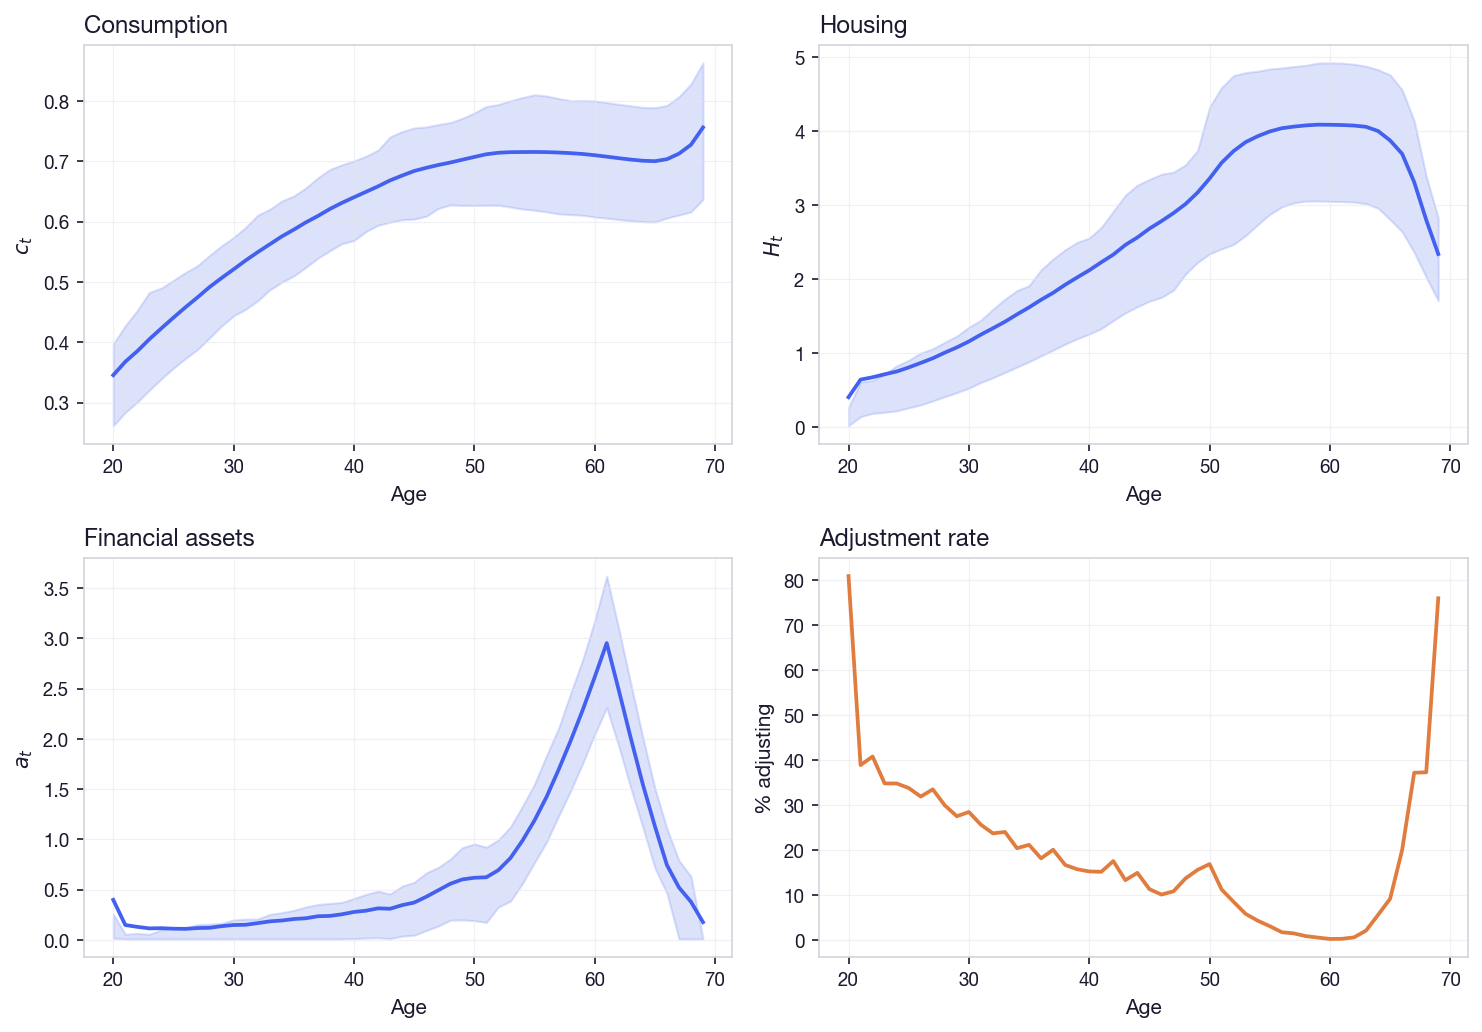

In [ ]:
from IPython.display import Image, display

for method in ['FUES', 'NEGM']:
    er = euler_results[method]
    r = results[method]
    plot_lifecycle(er['sim_data'], er['euler'], r['nest'],
                   output_dir=f'_nb_plots/{method}')
    path = f'_nb_plots/{method}/simulation/lifecycle.png'
    if os.path.exists(path):
        print(f'{labels[method]}')
        display(Image(path))

In [ ]:
_st0 = results['FUES']['nest']['periods'][0]['stages']['keeper_cons']
_t0 = int(_st0.calibration['t0'])
_T = int(_st0.settings['T'])
_norm = 1.0 / float(_st0.settings['normalisation'])
labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}

for method in ['FUES', 'NEGM']:
    sd = euler_results[method]['sim_data']
    tbl = generate_cohort_table(sd, _t0, _T, _norm)
    display(Markdown(f'**{labels[method]}**\n\n{tbl}'))

**EGM(FUES)**

| Age | $\bar{c}$ | SD($c$) | $\bar{a}$ | SD($a$) | $\bar{H}$ | SD($H$) |
|:---|---:|---:|---:|---:|---:|---:|
| 20–24 | 38,531.62 | 12,192.42 | 18,173.23 | 59,311.19 | 63,727.02 | 104,547.97 |
| 25–29 | 47,422.50 | 10,737.09 | 11,943.13 | 23,983.13 | 93,783.55 | 96,679.37 |
| 30–34 | 54,869.32 | 9,919.36 | 16,881.73 | 23,404.38 | 133,834.42 | 96,137.52 |
| 35–39 | 60,920.36 | 9,613.83 | 23,063.50 | 27,702.61 | 182,013.32 | 101,856.39 |
| 40–44 | 65,835.88 | 9,688.41 | 30,787.81 | 34,450.94 | 234,076.29 | 112,111.75 |
| 45–49 | 69,333.88 | 10,066.84 | 48,961.88 | 46,101.49 | 291,012.52 | 125,979.46 |
| 50–54 | 71,264.43 | 11,202.71 | 75,065.26 | 57,248.05 | 368,665.26 | 142,239.80 |
| 55–59 | 71,398.19 | 12,546.25 | 170,923.44 | 79,334.07 | 405,534.39 | 143,737.46 |
| 60–64 | 70,528.68 | 12,850.59 | 231,434.94 | 96,038.95 | 406,406.63 | 143,825.55 |
| 65–69 | 72,004.74 | 13,949.39 | 62,115.35 | 55,035.38 | 317,510.79 | 134,268.78 |

**NEGM(FUES)**

| Age | $\bar{c}$ | SD($c$) | $\bar{a}$ | SD($a$) | $\bar{H}$ | SD($H$) |
|:---|---:|---:|---:|---:|---:|---:|
| 20–24 | 38,535.88 | 12,194.13 | 18,193.06 | 59,314.13 | 63,712.73 | 104,541.71 |
| 25–29 | 47,418.88 | 10,737.39 | 11,960.76 | 23,986.20 | 93,774.51 | 96,670.97 |
| 30–34 | 54,860.69 | 9,926.34 | 16,889.95 | 23,435.07 | 133,858.33 | 96,107.32 |
| 35–39 | 60,918.09 | 9,620.12 | 23,066.34 | 27,690.47 | 182,065.16 | 101,861.92 |
| 40–44 | 65,836.09 | 9,676.64 | 30,793.44 | 34,448.79 | 234,122.38 | 112,183.99 |
| 45–49 | 69,323.53 | 10,064.13 | 49,083.99 | 46,105.57 | 290,931.38 | 125,930.16 |
| 50–54 | 71,242.65 | 11,199.94 | 74,757.39 | 57,316.91 | 369,070.03 | 141,822.69 |
| 55–59 | 71,389.12 | 12,553.18 | 171,330.42 | 79,299.93 | 405,344.13 | 143,685.54 |
| 60–64 | 70,506.73 | 12,862.00 | 232,057.69 | 95,957.36 | 406,203.00 | 143,543.07 |
| 65–69 | 71,966.48 | 13,977.17 | 59,118.24 | 54,715.60 | 320,464.23 | 132,505.46 |